In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

In [2]:
import torch.nn as nn
import torch
from seqAE_model import SeqAutoencoder
from contra_seq_dataset import *
from torch.utils.data import DataLoader, RandomSampler
from tqdm import tqdm

def get_latents(model_tag, csv_name, load_bs=32):
    
    tag = model_tag
    bs = load_bs

    n_epochs = 30
    use_cuda = True
    empty_cuda = True
    cuda_ids = [0,1,2,3]
    model = SeqAutoencoder(dim_emb=512, heads=8, dim_hidden=32,
                           L_enc=6, L_dec=6, dim_ff=2048, 
                           drpt=0.1, actv='relu', eps=0.6, b_first=True)

    p = f'/home/kat/Repos/SALSA/results/models/{tag}/{n_epochs-1:02}.pt'
    model.load_state_dict(torch.load(p), strict = False)
    if empty_cuda:
        torch.cuda.empty_cache()
    if use_cuda:
        if len(cuda_ids) == 1:
            cuda_id = cuda_ids[0]
            device = torch.device(f"cuda:{cuda_id}")
        elif len(cuda_ids) > 1:
            device =  torch.device("cuda")
            print(f"Using {len(cuda_ids)} GPUs!")
            model = nn.DataParallel(model, device_ids=cuda_ids)
            model.to(device)
    else:
        device = torch.device("cpu")
        model = model.to(device)
    model = model.eval()
    print(f"Loaded model weights from {p}!")

    ds = ContraSeqDataset(csv_name)
    df = get_dataset_array(csv_name)

    loader = DataLoader(ds, batch_size=bs, sampler=range(len(df)), 
                        num_workers=0, pin_memory=True)
    latents = []
    for samp in tqdm(loader, total=len(df)//bs):
        for k,v in samp.items():
            if torch.is_tensor(v):
                samp[k] = v.to(device)
        latent, _ = model.forward(samp['seq'], samp['pad_mask'], 
                                  samp['avg_mask'], samp['out_mask'])
        latent = latent.cpu().detach().numpy()
        latents.append(latent)
    latents = np.concatenate(latents, axis=0)
    
    return latents

In [3]:
from sklearn.metrics.pairwise import euclidean_distances
from scipy.spatial import distance
from utilities.fp_utils import get_fps_in_parallel
import numpy as np

csv_name = '20220603_extended_augset_1000anc_10iters.csv'
df = pd.read_csv(csv_name)
tags = ['2022041804_04',  # salsa
        '2022041807_a03', # contrastive  
        '2022041809_a04', # vanilla ae
        'morgan'] 

tag_to_dists = {}
for tag in tags:
    if tag=='morgan':
        smis = df.smiles
        fps = get_fps_in_parallel(smis,fp_type='morgan',counts=False,bits=1024,radius=4)
        latents = np.stack(fps)
    else:
        latents = get_latents(tag, csv_name=csv_name, load_bs=64)
    
    depths = [1,2,3,4,5,6,7,8,9,10]
    depth_to_dists = {}
    
    for depth in depths:

        depth_idc = df.index[[df.aug_iter==depth]].tolist()
        df_depth = df.loc[depth_idc]
        print(df_depth.shape, latents.shape)

        dists = []
        for i in df_depth.anc_idx.unique():

            anc_latent = latents[i]
            aug_idc = df_depth.index[[df_depth.anc_idx==i]].tolist() 
            aug_latents = latents[aug_idc]

            for aug_latent in aug_latents:
                d = distance.euclidean(anc_latent, aug_latent)
                dists.append(d)
                
        depth_to_dists[depth] = dists
        
    if tag=='2022041804_04':
        tag_to_dists['salsa'] = depth_to_dists
    elif tag=='2022041807_a03':
        tag_to_dists['contrastive encoder'] = depth_to_dists
    elif tag=='2022041809_a04':
        tag_to_dists['vanilla AE'] = depth_to_dists   
    else:
         tag_to_dists['morgan'] = depth_to_dists   

Using 4 GPUs!
Loaded model weights from /home/kat/Repos/SALSA/results/models/2022041804_04/29.pt!


1447it [03:29,  6.90it/s]                          


(6259, 5) (92594, 32)
(9212, 5) (92594, 32)
(9468, 5) (92594, 32)
(9519, 5) (92594, 32)
(9481, 5) (92594, 32)
(9522, 5) (92594, 32)
(9535, 5) (92594, 32)
(9566, 5) (92594, 32)
(9527, 5) (92594, 32)
(9505, 5) (92594, 32)
Using 4 GPUs!
Loaded model weights from /home/kat/Repos/SALSA/results/models/2022041807_a03/29.pt!


1447it [03:27,  6.97it/s]                          


(6259, 5) (92594, 32)
(9212, 5) (92594, 32)
(9468, 5) (92594, 32)
(9519, 5) (92594, 32)
(9481, 5) (92594, 32)
(9522, 5) (92594, 32)
(9535, 5) (92594, 32)
(9566, 5) (92594, 32)
(9527, 5) (92594, 32)
(9505, 5) (92594, 32)
Using 4 GPUs!
Loaded model weights from /home/kat/Repos/SALSA/results/models/2022041809_a04/29.pt!


1447it [03:29,  6.90it/s]                          


(6259, 5) (92594, 32)
(9212, 5) (92594, 32)
(9468, 5) (92594, 32)
(9519, 5) (92594, 32)
(9481, 5) (92594, 32)
(9522, 5) (92594, 32)
(9535, 5) (92594, 32)
(9566, 5) (92594, 32)
(9527, 5) (92594, 32)
(9505, 5) (92594, 32)
(6259, 5) (92594, 1024)
(9212, 5) (92594, 1024)
(9468, 5) (92594, 1024)
(9519, 5) (92594, 1024)
(9481, 5) (92594, 1024)
(9522, 5) (92594, 1024)
(9535, 5) (92594, 1024)
(9566, 5) (92594, 1024)
(9527, 5) (92594, 1024)
(9505, 5) (92594, 1024)


In [4]:
csv_name = '20220603_extended_augset_1000anc_10iters.csv'
df = pd.read_csv(csv_name)

smis = df.smiles
fps = get_fps_in_parallel(smis,fp_type='morgan',counts=False,bits=1024,radius=4)
fps = np.stack(fps)

fps_norm = np.linalg.norm(fps, ord=2, axis=1)[:,np.newaxis]

fps_normed = fps/fps_norm
print(fps_normed.shape)

depths = [1,2,3,4,5,6,7,8,9,10]
depth_to_dists = {}

for depth in depths:

    depth_idc = df.index[[df.aug_iter==depth]].tolist()
    df_depth = df.loc[depth_idc]

    dists = []
    for i in df_depth.anc_idx.unique():

        anc_latent = fps_normed[i]
        aug_idc = df_depth.index[[df_depth.anc_idx==i]].tolist() 
        aug_latents = fps_normed[aug_idc]

        for aug_latent in aug_latents:
            d = distance.euclidean(anc_latent, aug_latent)
            dists.append(d)

    depth_to_dists[depth] = dists

# res = np.einsum('ia, ia -> i', fps_normed, fps_normed)    
tag_to_dists['morgan_normed'] = depth_to_dists

(92594, 1024)


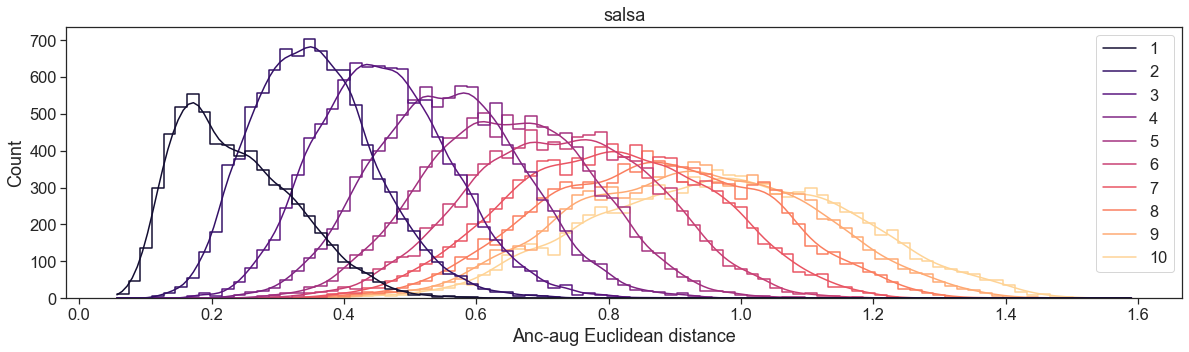

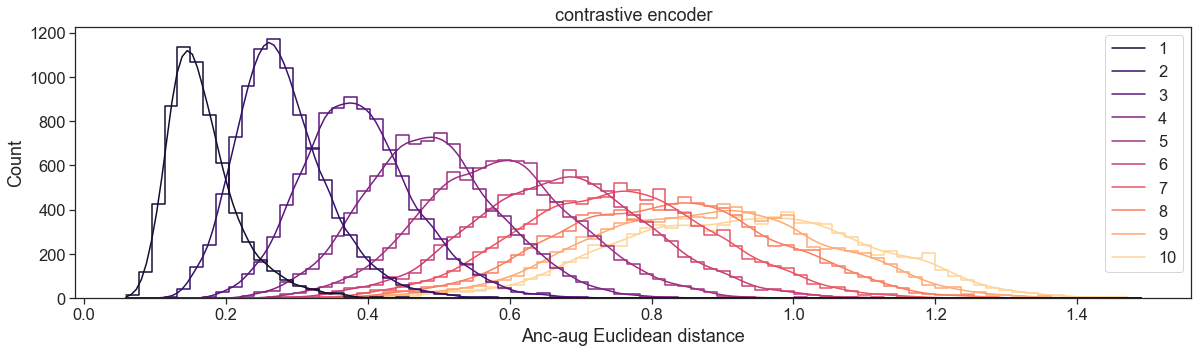

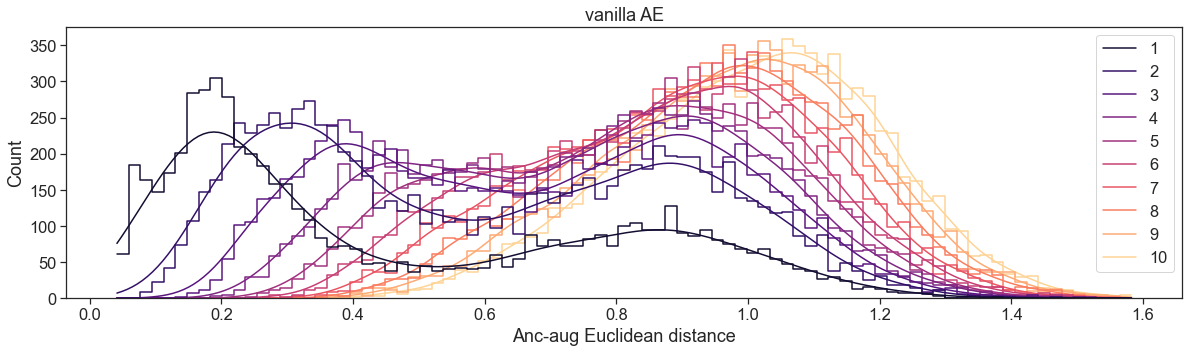

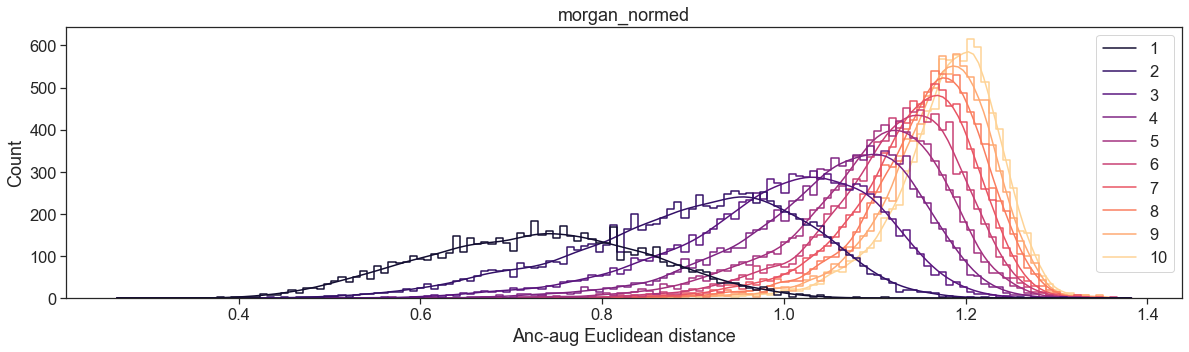

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='ticks',font_scale=1.5,palette='muted',)

for k,v in tag_to_dists.items():
    if k=='morgan':
        continue
    plt.figure(figsize=(20,5))
    sns.histplot(v, fill=False, element="step", kde=True, palette='magma')
    plt.xlabel('Anc-aug Euclidean distance')
    plt.title(k)
    plt.show() 

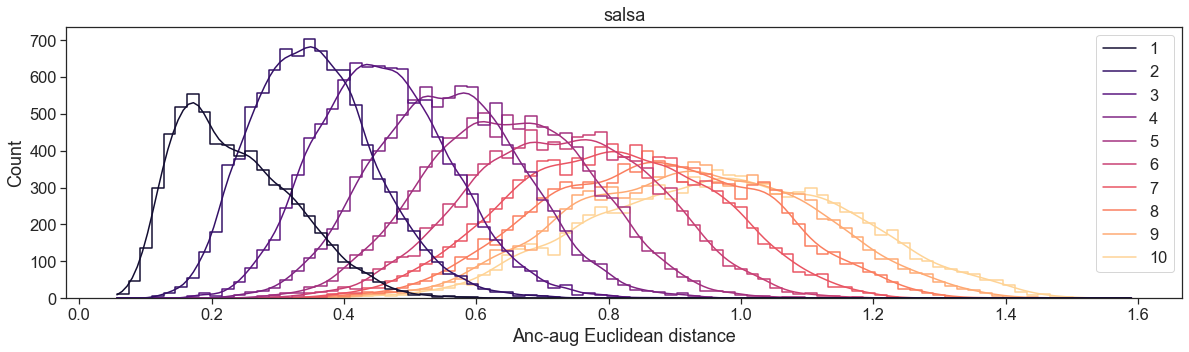

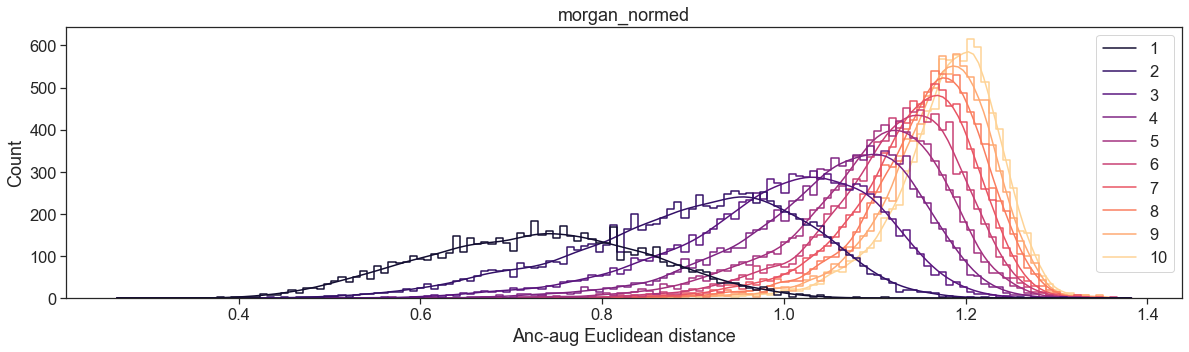

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='ticks',font_scale=1.5,palette='muted',)

for k,v in tag_to_dists.items():
    if k in ['salsa','morgan_normed']:
        plt.figure(figsize=(20,5))
        sns.histplot(v, fill=False, element="step", kde=True, palette='magma')
        plt.xlabel('Anc-aug Euclidean distance')
        plt.title(k)
        plt.show() 

In [38]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

tag_to_auc = {}

for v in ['salsa','morgan_normed']:
    
    roc_aucs = []
    
    for idx2 in depths[1:]:

        idx1 = 1

        y_score1 = tag_to_dists[v][idx1]
        y_score2 = tag_to_dists[v][idx2]
        y_score = np.hstack([y_score1, y_score2])

        y_true1 = np.full(len(y_score1), idx1)
        y_true2 = np.full(len(y_score2), idx2)
        y_true = np.hstack([y_true1, y_true2])

        fpr, tpr, thresholds = roc_curve(y_true, y_score, pos_label=idx2)
        roc_auc = auc(fpr, tpr)
        roc_aucs.append(roc_auc)
        
    tag_to_auc[v] = roc_aucs

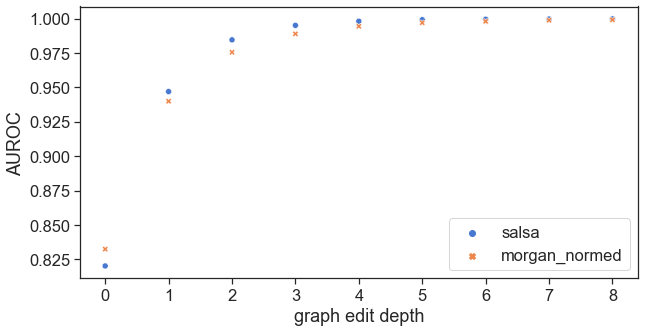

In [58]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=tag_to_auc)
plt.xlabel('graph edit depth')
plt.ylabel('AUROC')
plt.show()

In [60]:
tag_to_auc = {}

for v in ['salsa','morgan_normed']:
    
    roc_aucs = []
    
    for (idx1,idx2) in zip(depths,depths[1:]):

        y_score1 = tag_to_dists[v][idx1]
        y_score2 = tag_to_dists[v][idx2]
        y_score = np.hstack([y_score1, y_score2])

        y_true1 = np.full(len(y_score1), idx1)
        y_true2 = np.full(len(y_score2), idx2)
        y_true = np.hstack([y_true1, y_true2])

        fpr, tpr, thresholds = roc_curve(y_true, y_score, pos_label=idx2)
        roc_auc = auc(fpr, tpr)
        roc_aucs.append(roc_auc)
        
    tag_to_auc[v] = roc_aucs

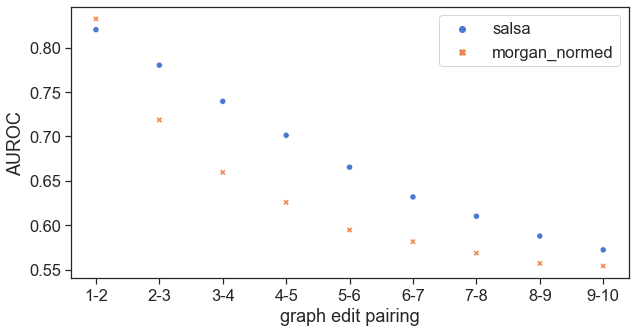

In [67]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=tag_to_auc)
plt.xlabel('graph edit pairing')
plt.ylabel('AUROC')

labs = [f'{i}-{j}' for (i,j) in zip(depths,depths[1:])]
plt.xticks(range(len(labs)), labs)
plt.show()

In [68]:
from scipy import stats
for v in ['salsa','morgan_normed']:
    print('\n',v)
    for idx1, idx2 in zip(depths, depths[1:]):
        dist1 = tag_to_dists[v][idx1]
        dist2 = tag_to_dists[v][idx2]
#         ks = stats.ks_2samp(dist1, dist2)
        ks = stats.kstest(dist1, dist2)
        print(f'{idx1} - {idx2:2} KS stat: {round(ks[0], 3)}, pvalue: {ks[1]}') 


 salsa
1 -  2 KS stat: 0.483, pvalue: 1.0
2 -  3 KS stat: 0.416, pvalue: 1.0
3 -  4 KS stat: 0.353, pvalue: 1.0
4 -  5 KS stat: 0.29, pvalue: 1.0
5 -  6 KS stat: 0.237, pvalue: 0.9991687574903897
6 -  7 KS stat: 0.187, pvalue: 0.0004503484266061841
7 -  8 KS stat: 0.158, pvalue: 1.446620601086579e-11
8 -  9 KS stat: 0.125, pvalue: 1.0103029524088925e-14
9 - 10 KS stat: 0.104, pvalue: 2.3017430313244572e-45

 morgan_normed
1 -  2 KS stat: 0.519, pvalue: 1.0
2 -  3 KS stat: 0.322, pvalue: 1.0
3 -  4 KS stat: 0.237, pvalue: 0.9991105156066266
4 -  5 KS stat: 0.188, pvalue: 0.0005432798027782404
5 -  6 KS stat: 0.138, pvalue: 9.923941276208528e-80
6 -  7 KS stat: 0.122, pvalue: 1.7840157840322175e-62
7 -  8 KS stat: 0.102, pvalue: 4.773959005888173e-15
8 -  9 KS stat: 0.086, pvalue: 1.0103029524088925e-14
9 - 10 KS stat: 0.083, pvalue: 3.224887667885749e-29


In [54]:
from scipy import stats
for v in ['salsa','morgan_normed']:
    print('\n',v)
    for idx2 in depths[1:]:
        idx1 = 1
        dist1 = tag_to_dists[v][idx1]
        dist2 = tag_to_dists[v][idx2]
        ks = stats.ks_2samp(dist1, dist2)
        print(f'{idx1} - {idx2:2} KS stat: {round(ks[0], 3)}, pvalue: {ks[1]}') 


 salsa
1 -  2 KS stat: 0.483, pvalue: 1.0
1 -  3 KS stat: 0.746, pvalue: 1.0
1 -  4 KS stat: 0.876, pvalue: 1.0
1 -  5 KS stat: 0.932, pvalue: 1.0
1 -  6 KS stat: 0.963, pvalue: 1.0
1 -  7 KS stat: 0.976, pvalue: 1.0
1 -  8 KS stat: 0.983, pvalue: 1.0
1 -  9 KS stat: 0.987, pvalue: 1.0
1 - 10 KS stat: 0.99, pvalue: 1.0

 morgan_normed
1 -  2 KS stat: 0.519, pvalue: 1.0
1 -  3 KS stat: 0.738, pvalue: 1.0
1 -  4 KS stat: 0.846, pvalue: 1.0
1 -  5 KS stat: 0.902, pvalue: 1.0
1 -  6 KS stat: 0.934, pvalue: 1.0
1 -  7 KS stat: 0.953, pvalue: 1.0
1 -  8 KS stat: 0.968, pvalue: 1.0
1 -  9 KS stat: 0.976, pvalue: 1.0
1 - 10 KS stat: 0.983, pvalue: 1.0
